KulingNet - Cloud Image Classifier
- Based on: CCSN dataset, contains 2543 cloud images. 
- According to the World Meterological Organization’s genera-based classification recommendation, we divide into 11 different categories：

Ci = cirrus; 
Cs = cirrostratus; 
Cc = cirrocumulus; 
Ac = altocumulus; 
As = altostratus; 
Cu = cumulus; 
Cb = cumulonimbus; 
Ns = nimbostratus; 
Sc = stratocumulus; 
St = stratus; 
Ct = contrail.


All images are fixed resolution 256×256 pixels with the JPEG format.

-----------------------------------------------------------------------

In [3]:
# Imports <
import numpy as np, pandas as pd
import os 

# For image processing
from PIL import Image
from IPython.display import Image

# Pytorch 
import torch
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

import torchvision
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torchmetrics import Precision, Recall

# Plotting
import matplotlib.pyplot as plt


In [4]:
# Where we are right now, absolute pathing  
base_dir = os.path.abspath('')
images_file_path = os.path.join(base_dir, "CCSN_Image_set")
# example path for cirrus clouds
ci_file_path = os.path.join(images_file_path, "Ci")

print(f"Cirrus filepath: {ci_file_path}")
print(f"Root filepath: {images_file_path}")

Cirrus filepath: c:\Users\Admin\Documents\Chalmers\Programmering\KulingNet\CCSN_Image_set\Ci
Root filepath: c:\Users\Admin\Documents\Chalmers\Programmering\KulingNet\CCSN_Image_set


In [6]:
# Tensor ~ vector (array of components)
# Compose allows for list of several transformations simultanously 
transform = transforms.Compose([
    # to fit with current NN
    #transforms.Resize((32,32)),
    # Input images as 0-255 RGB-values, we want in range [-1,1]
    # Converts PIL [0,255] to [0.0, 1.0]
    transforms.ToTensor(),
    
    # Adjusts with mean=0.5, stdv=0.5 
    # 3 Channels because of RGB (Greyscale would be 1 channel)
    #transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))

    transforms.Resize(256),

    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2)
])

# Create the full dataset
full_dataset = datasets.ImageFolder(root=images_file_path, transform=transform)
# Example image size
full_dataset[0][0].size()

"""
# Create names
images = full_dataset.imgs
name_list = []
for file_name in images:
    file_name = file_name[0][len(file_name)-13:]
    file_name = file_name[:-4]
    name_list.append(file_name)

#name_list
"""

'\n# Create names\nimages = full_dataset.imgs\nname_list = []\nfor file_name in images:\n    file_name = file_name[0][len(file_name)-13:]\n    file_name = file_name[:-4]\n    name_list.append(file_name)\n\n#name_list\n'

In [7]:
# Labels
class_names = ["altocumulus", "altostratus", "cumulonimbus", "cirrocumulus", 
               "cirrus", "cirrostratus", "contrail", "cumulus", "nimbostratus", 
               "stratocumulus", "stratus"]


In [8]:
# Train, test split
train_data, test_data = torch.utils.data.random_split(full_dataset,[0.8,0.2])

train_loader = torch.utils.data.DataLoader(train_data, batch_size=32, shuffle=True)
# No shuffling since no training is done, randomness not needed
test_loader = torch.utils.data.DataLoader(train_data, batch_size=32, shuffle=False)

full_dataset.class_to_idx

{'Ac': 0,
 'As': 1,
 'Cb': 2,
 'Cc': 3,
 'Ci': 4,
 'Cs': 5,
 'Ct': 6,
 'Cu': 7,
 'Ns': 8,
 'Sc': 9,
 'St': 10}

torch.Size([3, 256, 256])
Cloud type: stratocumulus, label: 9


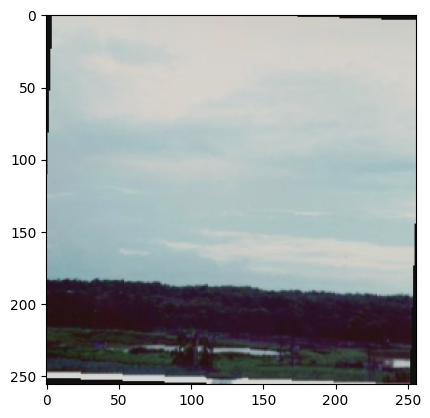

In [9]:
image, label = train_data[0]
# 3 channel 32x32 images
print(image.size())
# Print name???
print(f"Cloud type: {class_names[label]}, label: {label}")

image = image.squeeze().permute(1, 2, 0)

plt.imshow(image)
plt.show()

In [10]:
Image("2D-CNN-layer-calculation.png")

class KulingNet(nn.Module):
    # Create base nn-architecture
    def __init__(self):
        super().__init__()
        self.name = "KulingNet"  
        # 5x5 kernel moves across images, creates feature maps
        # out_channels double after each pooling
        self.conv1 = nn.Conv2d(3, 16, kernel_size=5, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=5, padding=1) 
        self.conv3 = nn.Conv2d(32, 64, kernel_size=5, padding=1)

        # Pools together 2x2 pixels to single pixel (extracts important features)
        self.pool = nn.MaxPool2d(kernel_size=2) 

        # "Dense" layers, neurons have to be compatible, but chosen freely
        # 50 because pooling 2x2 three times 400 -> 50
        self.fc1 = nn.Linear(64*30*30, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84,11)

        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
    
    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))

        #print(x.shape)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)

        return x
    

In [ ]:
net = KulingNet()
loss_function = nn.CrossEntropyLoss()
# lr: step size during gradient descent
# momentum: using past gradients (inertia)
optimizer = optim.SGD(net.parameters(), lr = 0.001, momentum=0.9)

In [12]:

for epoch in range(30):
    print("Training epoch:", epoch+1, "...")
    running_loss = 0.0
    for i, data in enumerate(train_loader):
        # each batch contains data
        inputs, labels = data

        optimizer.zero_grad()

        outputs = net(inputs)
        # Calculate difference of predicted vs actual labels
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    print(f"Running loss: {running_loss / len(train_loader):.4f}")


Training epoch: 1 ...


KeyboardInterrupt: 

In [151]:
# Save net parameters
torch.save(net.state_dict(), "KulingNet_trained.pth")

In [13]:
# Load net with parameters
net = KulingNet()
net.load_state_dict(torch.load("KulingNet_trained.pth"))

<All keys matched successfully>

In [14]:
# Checking the network
correct = 0
total = 0 

precision = Precision(task="multiclass", num_classes=11, average="weighted")
recall = Recall(task="multiclass", num_classes=11, average="weighted")

net.eval()
# no gradient descent during evaluation, just feed input forward
with torch.no_grad():
    for images, labels in test_loader:
        # feed test through net
        outputs = net(images)
        
        # find prediction (highest probability)
        _ , predicted = torch.max(outputs, 1)

        total += labels.size(0)

        # Compute metrics
        precision(predicted,labels)
        recall(predicted,labels)
        correct += (predicted == labels).sum().item()


prec_score = precision.compute()
rec_score = recall.compute()

accuracy = 100 * correct / total

print(f"Accuracy: {accuracy} %",
    f"Precision Score: {prec_score}",
    f"Recall Score: {rec_score}",
    sep="\n"
)


Accuracy: 34.054054054054056 %
Precision Score: 0.33597254753112793
Recall Score: 0.3405405580997467


In [ ]:

# Transform test images with different format 
new_transform = transforms.Compose([
    transforms.Resize((32,32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
])

def load_image(path):
    image = Image.open(path)
    image = new_transform(image)
    # Add batch dimension
    image = image.unsqueeze(0)
    return image

paths = []
images = [load_image(img) for img in paths]

net.eval()
with torch.no_grad():
    for image in images:
        output = net(image)
        _, predicted = torch.max(output,1)
        print(f"Prediction: {class_names[predicted.item()]}")
